In [1]:
import cv2

In [2]:
vidname = 'highway1'
vidcap = cv2.VideoCapture(f'videos/{vidname}.mov')
success,image = vidcap.read()
count = 0
while success:
  cv2.imwrite(f'frames/{vidname}/frame%d.jpg' % count, image)      
  success,image = vidcap.read()
  count += 100

In [3]:
start = 84000
end = 129000

In [4]:
import sys
sys.path.insert(0, './Vehicle-Detection')

In [7]:
import matplotlib
matplotlib.use('Agg')  # Use non-interactive backend to avoid conflicts

from ultralytics import YOLO

In [ ]:
model = YOLO('yolov5m.pt')  # Auto-downloads

results = model.predict('videos/highway1.mov', conf=0.5)

PRO TIP 💡 Replace 'model=yolov5m.pt' with new 'model=yolov5mu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/5253) /Users/tanishasingh/Documents copy/UCI/Y3Q3/117_final/videos/highway1.mov: 384x640 4 cars, 1 traffic light, 193.3ms
video 1/1 (frame 2/5253) /Users/tanishasingh/Documents copy/

In [ ]:
import matplotlib.pyplot as plt

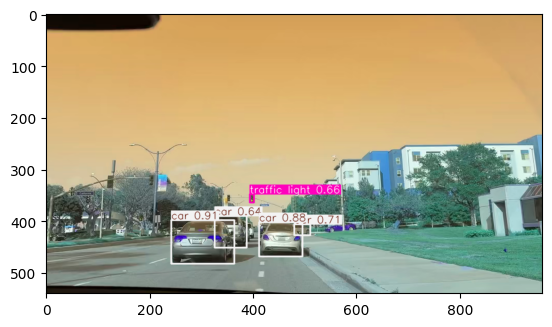

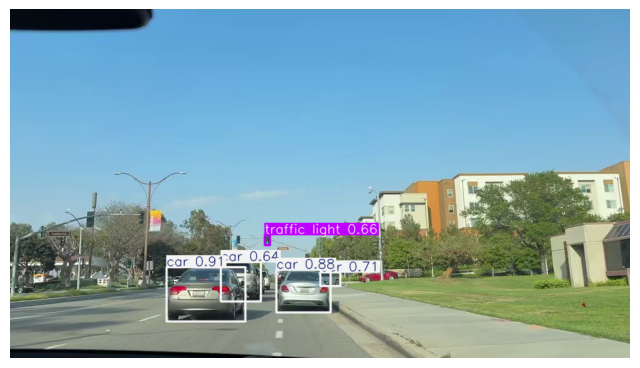

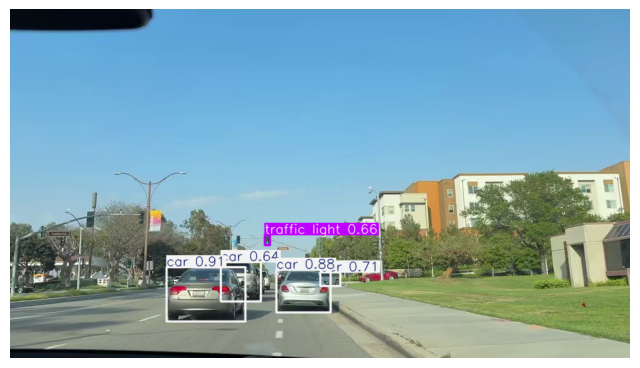

In [ ]:
annotated_frame = results[0].plot() 
%matplotlib inline
plt.figure(figsize=(8, 6))
plt.imshow(annotated_frame[:, :, ::-1]) #BGR->RGB
plt.axis("off")
plt.show()

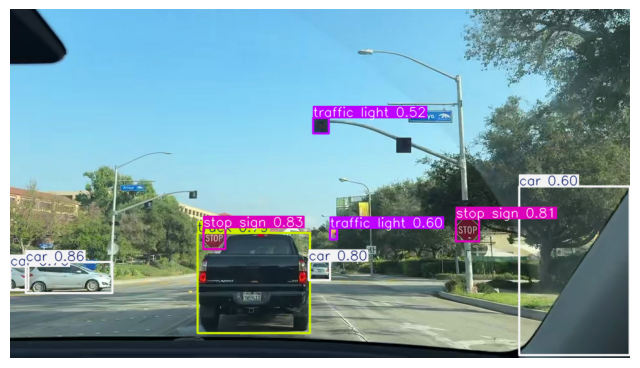

In [21]:
annotated_frame = results[1000].plot() 
%matplotlib inline
plt.figure(figsize=(8, 6))
plt.imshow(annotated_frame[:, :, ::-1]) #BGR->RGB
plt.axis("off")
plt.show()

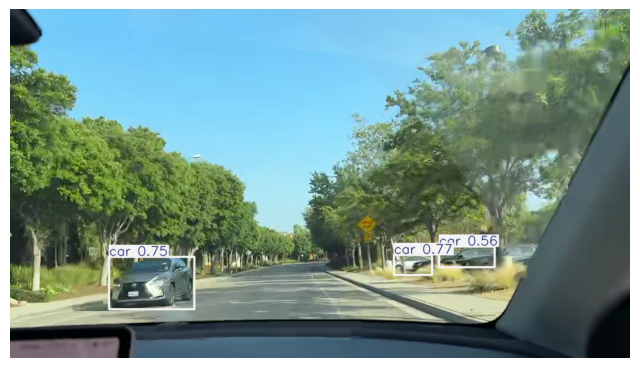

In [28]:
annotated_frame = results[3462].plot() 
%matplotlib inline
plt.figure(figsize=(8, 6))
plt.imshow(annotated_frame[:, :, ::-1]) #BGR->RGB
plt.axis("off")
plt.show()

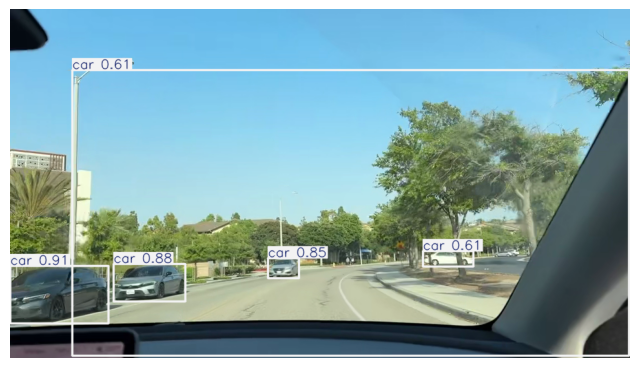

In [29]:
annotated_frame = results[2685].plot() 
%matplotlib inline
plt.figure(figsize=(8, 6))
plt.imshow(annotated_frame[:, :, ::-1]) #BGR->RGB
plt.axis("off")
plt.show()

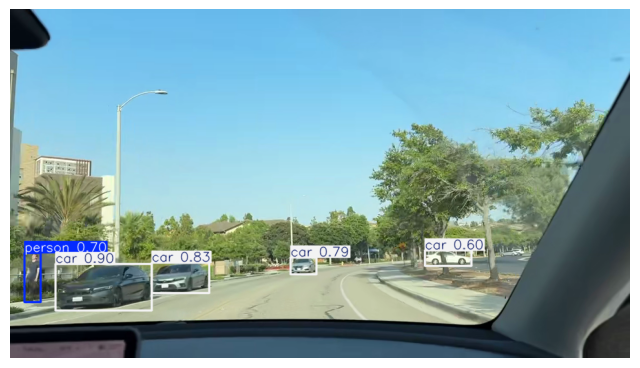

In [34]:
annotated_frame = results[2675].plot() 
%matplotlib inline
plt.figure(figsize=(8, 6))
plt.imshow(annotated_frame[:, :, ::-1]) #BGR->RGB
plt.axis("off")
plt.show()

In [35]:
import numpy as np
def triangulate(pts2L,camL,pts2R,camR):
    """
    Triangulate the set of points seen at location pts2L / pts2R in the
    corresponding pair of cameras. Return the 3D coordinates relative
    to the global coordinate system


    Parameters
    ----------
    pts2L : 2D numpy.array (dtype=float)
        Coordinates of N points stored in a array of shape (2,N) seen from camL camera

    pts2R : 2D numpy.array (dtype=float)
        Coordinates of N points stored in a array of shape (2,N) seen from camR camera

    camL : Camera
        The first "left" camera view

    camR : Camera
        The second "right" camera view

    Returns
    -------
    pts3 : 2D numpy.array (dtype=float)
        (3,N) array containing 3D coordinates of the points in global coordinates

    """

    #
    # Your code goes here.  I recommend adding assert statements to check the
    # sizes of the inputs and outputs to make sure they are correct 
    #

    assert(pts2L.shape[0] == 2)
    assert(pts2R.shape[0] == 2)

    pts3 = np.zeros([3, pts2L.shape[1]])

    xL_cam = (pts2L[0, :] - camL.c[0])/camL.f
    yL_cam = (pts2L[1, :] - camL.c[1])/camL.f
    q_L = np.vstack([xL_cam, yL_cam, np.ones(xL_cam.shape)])

    xR_cam = (pts2R[0, :] - camR.c[0])/camR.f
    yR_cam = (pts2R[1, :] - camR.c[1])/camR.f
    q_R = np.vstack([xR_cam, yR_cam, np.ones(xR_cam.shape)])

    b = camR.t - camL.t
    for i in range(len(pts2L[0])):
        q_L_i = q_L[:, i].reshape((3,1))
        q_R_i = q_R[:, i].reshape((3,1))
        A_i = np.hstack([camL.R@q_L_i, -1*camR.R@q_R_i])
        u, *_ = np.linalg.lstsq(A_i, b)
        z_L, z_R = u[0], u[1]

        P_L = z_L * q_L_i 
        P_1 = (camL.R @ P_L) + camL.t
        
        P_R = z_R * q_R_i 
        P_2 = (camR.R @ P_R) + camR.t

        pts3[:, i] = ((P_1 + P_2)/2).T

    assert(pts3.shape[0] == 3)

    return pts3

In [ ]:
imgs = []

fig = plt.figure()

#select points in base image
ax1 = fig.add_subplot(2,1,1)
ax1.imshow(imgs[baseim],cmap=plt.cm.gray)

#corresponding points in overlapping image
ax2 = fig.add_subplot(2,1,2)
ax2.imshow(imgs[i],cmap=plt.cm.gray)

sp1 = selectpoints.select_k_points(ax1,npoints)
sp2 = selectpoints.select_k_points(ax2,npoints)

pointmatches.append((sp1,sp2))
